## I modified from this code
https://github.com/nattaponm/radar_mosaic_thai_SF66/blob/main/14%E0%B8%9E%E0%B8%A5%E0%B8%AD%E0%B8%95%E0%B8%A0%E0%B8%B2%E0%B8%9E%E0%B9%80%E0%B8%A3%E0%B8%94%E0%B8%B2%E0%B8%A3%E0%B9%8C%E0%B9%82%E0%B8%A1%E0%B9%80%E0%B8%AA%E0%B8%84%E0%B8%A3%E0%B8%B2%E0%B8%A2%E0%B8%8A%E0%B8%B1%E0%B9%88%E0%B8%A7%E0%B9%82%E0%B8%A1%E0%B8%87%E0%B8%97%E0%B8%B1%E0%B9%89%E0%B8%87%E0%B9%80%E0%B8%94%E0%B8%B5%E0%B9%88%E0%B8%A2%E0%B8%A7%E0%B9%81%E0%B8%A5%E0%B8%B0%E0%B8%A0%E0%B8%B2%E0%B8%9E%E0%B8%81%E0%B8%A5%E0%B8%B8%E0%B9%88%E0%B8%A18%E0%B8%A0%E0%B8%B2%E0%B8%9E.ipynb


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking paths...
DATA_ROOT exists    : True
BASE_DIR exists     : True
SHAPEFILE exists    : True
GeoTIFF files found : 48
First file          : 2018071700.tif
Last file           : 2018071823.tif
✅ Loaded: 2018071701.tif
✅ Loaded: 2018071702.tif
✅ Loaded: 2018071703.tif
✅ Loaded: 2018071704.tif
✅ Loaded: 2018071705.tif
✅ Loaded: 2018071706.tif
✅ Loaded: 2018071707.tif
✅ Loaded: 2018071708.tif

Plotting 8 maps...


/tmp/ipykernel_646/3364060679.py:166: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


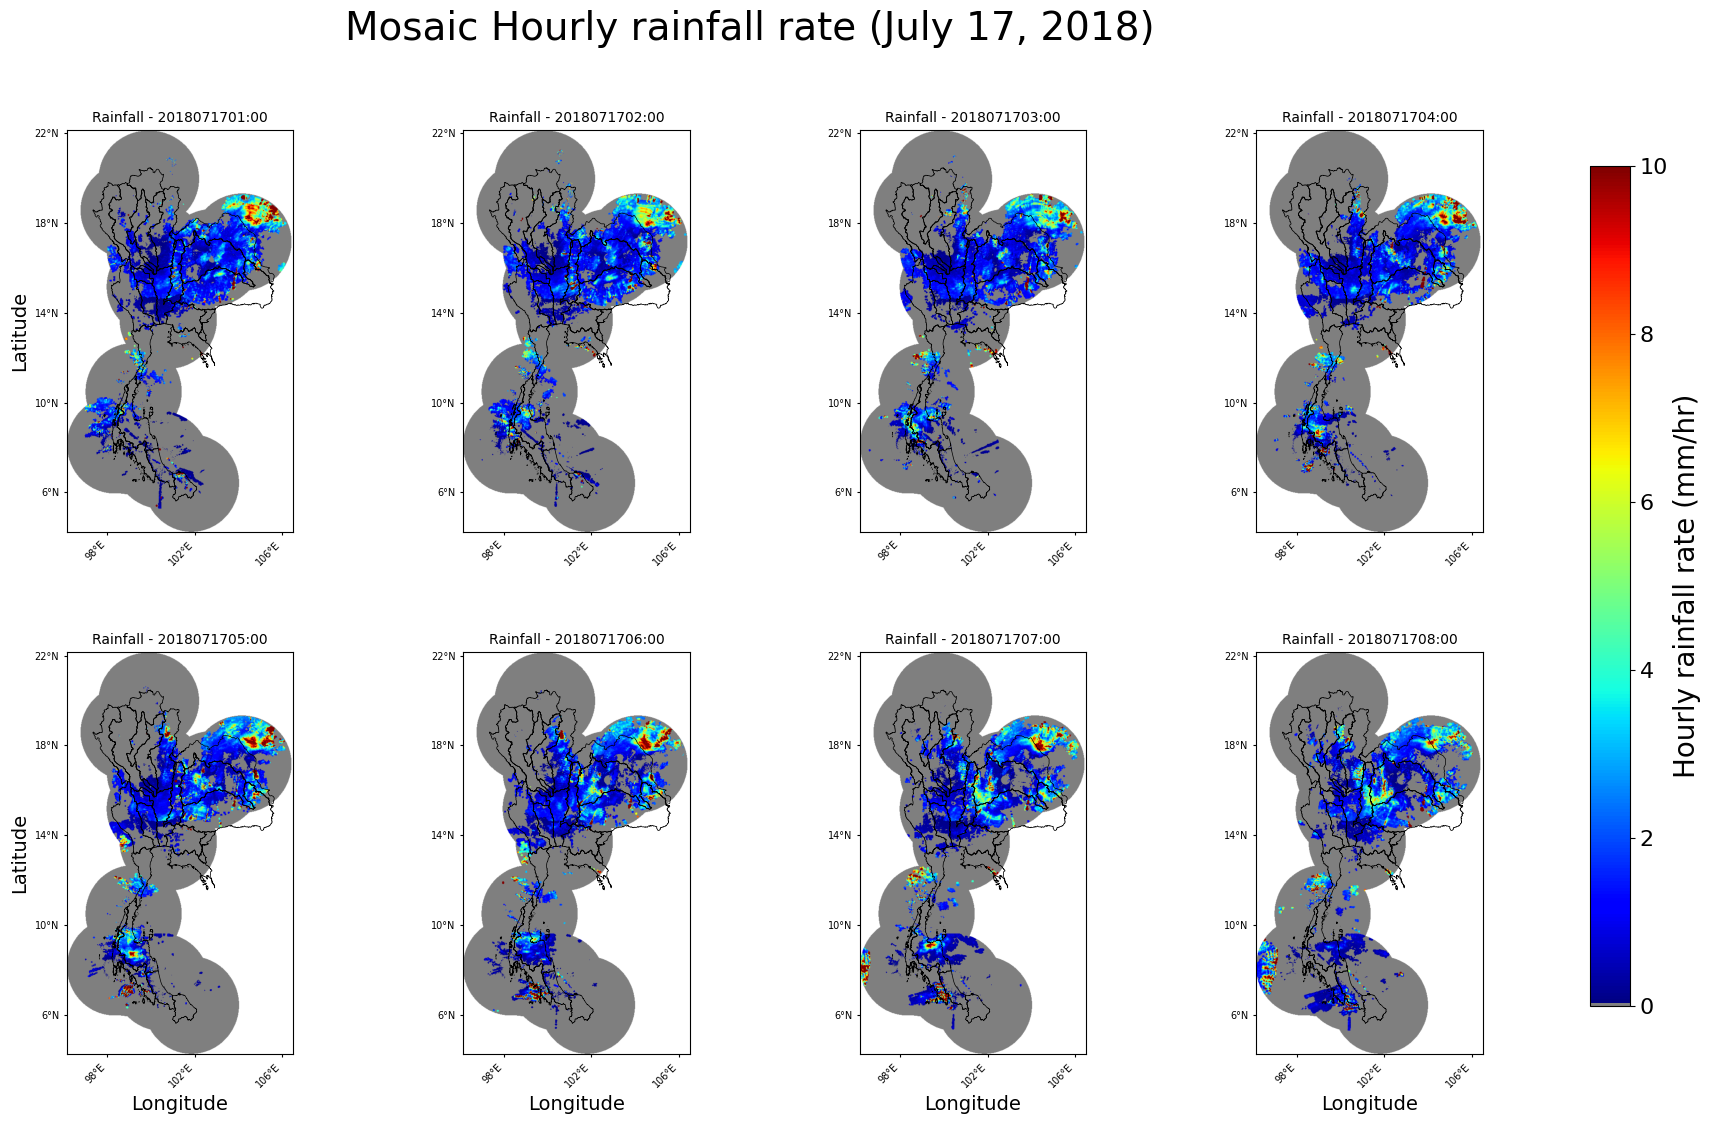

In [2]:
# ============================================================
# CELL 1 - Install required libraries
# ============================================================
!pip install rasterio geopandas pyproj -q


# ============================================================
# CELL 2 - Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


# ============================================================
# CELL 3 - Import libraries
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import rasterio
from rasterio.features import rasterize
import geopandas as gpd
from shapely.geometry import Polygon
from pyproj import Geod
from datetime import datetime, timedelta
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib.gridspec as gridspec

%matplotlib inline


# ============================================================
# CELL 4 - Set paths  (TRAINEES: only edit this cell)
# ============================================================

DATA_ROOT = "/content/drive/MyDrive/1shared_etc/000อบรมเรดาร์กรมชลประทาน/0data_radar_mos"

BASE_DIR        = f"{DATA_ROOT}/0radar_mosaic_geotif_samples/0mfb"
BASIN_SHAPEFILE = f"{DATA_ROOT}/0base_map_gis/MainBasin_ONWR_Law_WGS84Geo.shp"

TIME_HR = "2018071701"  # ← starting hour, will plot this + next 7 hours


# ============================================================
# CELL 5 - Verify paths (run this before main code!)
# ============================================================
print("=" * 50)
print("Checking paths...")
print(f"DATA_ROOT exists    : {os.path.exists(DATA_ROOT)}")
print(f"BASE_DIR exists     : {os.path.exists(BASE_DIR)}")
print(f"SHAPEFILE exists    : {os.path.exists(BASIN_SHAPEFILE)}")

if os.path.exists(BASE_DIR):
    tif_files = sorted([f for f in os.listdir(BASE_DIR) if f.endswith('.tif')])
    print(f"GeoTIFF files found : {len(tif_files)}")
    if tif_files:
        print(f"First file          : {tif_files[0]}")
        print(f"Last file           : {tif_files[-1]}")
    else:
        print("⚠️  No .tif files found — check subfolder structure")
        subfolders = [f for f in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, f))]
        print(f"Subfolders found    : {subfolders}")
elif os.path.exists(DATA_ROOT):
    print("\n⚠️  BASE_DIR not found. Contents of DATA_ROOT:")
    for item in os.listdir(DATA_ROOT):
        print(f"  {item}")
else:
    print("❌ DATA_ROOT not found — check shortcut path")
print("=" * 50)


# ============================================================
# CELL 6 - Define all functions
# ============================================================

def read_geotiff(file_path):
    with rasterio.open(file_path) as src:
        return src.read(1), src.transform, src.crs


def create_geodetic_radar_buffers(radar_dict, active_radars, radius_km, crs):
    geod = Geod(ellps="WGS84")
    azimuths = np.linspace(0, 360, 361)

    radar_data = [
        {'radar': radar, 'geometry': Polygon([
            geod.fwd(*radar_dict[radar]['coords'][:2], azimuth, radius_km * 1000)[:2]
            for azimuth in azimuths
        ])}
        for radar in active_radars
    ]

    return gpd.GeoDataFrame(radar_data, crs=crs)


def create_radar_mask(radar_buffers, shape, transform, crs):
    return rasterize(
        [(geom, 1) for geom in radar_buffers.geometry],
        out_shape=shape,
        transform=transform,
        fill=0,
        dtype=np.uint8
    )


def plot_multiple_rainfall_maps(data_list, mask_list, transform_list, crs_list,
                                 basin_shapefile, time_list, vmin=0, vmax=10):
    fig = plt.figure(figsize=(20, 12))
    gs = gridspec.GridSpec(2, 4, figure=fig, wspace=0.1, hspace=0.3)

    cmap = plt.cm.jet
    jet_colors = cmap(np.linspace(0, 1, 256))
    jet_colors[0] = [0.5, 0.5, 0.5, 1]   # grey for 0 mm
    custom_cmap = ListedColormap(jet_colors)
    custom_cmap.set_bad('white')           # white outside radar mask

    gdf = gpd.read_file(basin_shapefile)

    for i, (data, mask, transform, crs, time_hr) in enumerate(
            zip(data_list, mask_list, transform_list, crs_list, time_list)):

        ax = fig.add_subplot(gs[i // 4, i % 4])
        masked_data = np.ma.masked_where(mask == 0, data)

        extent = rasterio.transform.array_bounds(data.shape[0], data.shape[1], transform)
        extent = [extent[0], extent[2], extent[1], extent[3]]

        im = ax.imshow(masked_data, cmap=custom_cmap, extent=extent,
                       origin='upper', vmin=vmin, vmax=vmax)
        gdf.to_crs(crs).boundary.plot(ax=ax, color='black', linewidth=0.5)

        ax.set_title(f'Rainfall - {time_hr}:00', fontsize=10)
        ax.set_xlim(96.15, 106.5)
        ax.set_ylim(4.25, 22.15)

        lon_ticks = [98, 102, 106]
        lat_ticks = [6, 10, 14, 18, 22]

        ax.xaxis.set_major_locator(FixedLocator(lon_ticks))
        ax.xaxis.set_major_formatter(FixedFormatter([f'{x}°E' for x in lon_ticks]))
        ax.yaxis.set_major_locator(FixedLocator(lat_ticks))
        ax.yaxis.set_major_formatter(FixedFormatter([f'{y}°N' for y in lat_ticks]))

        ax.tick_params(axis='both', which='major', labelsize=7)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
        ax.tick_params(axis='both', which='both', length=2)

        if i % 4 == 0:
            ax.set_ylabel("Latitude", fontsize=14)
        if i // 4 == 1:
            ax.set_xlabel("Longitude", fontsize=14)

    # Single shared colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label("Hourly rainfall rate (mm/hr)", fontsize=20)
    cbar.ax.tick_params(labelsize=16)

    initial_datetime = datetime.strptime(time_list[0], "%Y%m%d%H")
    plt.suptitle(
        f"Mosaic Hourly rainfall rate ({initial_datetime.strftime('%B %d, %Y')})",
        fontsize=28, y=0.98
    )
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.show()


def main(initial_hour, base_dir, basin_shapefile, radar_dict, radius_km=240):

    initial_dt = datetime.strptime(initial_hour, '%Y%m%d%H')
    time_list = [(initial_dt + timedelta(hours=i)).strftime('%Y%m%d%H') for i in range(8)]

    data_list, mask_list, transform_list, crs_list = [], [], [], []

    # Use all radars (no mosaic report needed)
    available_radars = list(radar_dict.keys())

    for time_hr in time_list:
        file_path = os.path.join(base_dir, f"{time_hr}.tif")

        if not os.path.exists(file_path):
            print(f"⚠️  File not found: {file_path}")
            continue

        data, transform, crs = read_geotiff(file_path)
        radar_buffers = create_geodetic_radar_buffers(radar_dict, available_radars, radius_km, crs)
        radar_mask = create_radar_mask(radar_buffers, data.shape, transform, crs)

        data_list.append(data)
        mask_list.append(radar_mask)
        transform_list.append(transform)
        crs_list.append(crs)
        print(f"✅ Loaded: {time_hr}.tif")

    if len(data_list) == 0:
        print("❌ No data loaded — check BASE_DIR path and TIME_HR")
        return

    print(f"\nPlotting {len(data_list)} maps...")
    plot_multiple_rainfall_maps(
        data_list, mask_list, transform_list, crs_list,
        basin_shapefile, time_list
    )


# ============================================================
# CELL 7 - Radar dictionary
# ============================================================
radar_dict = {
    "CHN": {'coords': (100.191263, 15.157852, 40.0),  'el': 0.5},
    "CMP": {'coords': (99.188203,  10.493099, 32.0),  'el': 0.0},
    "CRI": {'coords': (99.881593,  19.961471, 444.0), 'el': 1.08},
    "KKN": {'coords': (102.785881, 16.4625,   217.0), 'el': 0.42},
    "KRB": {'coords': (98.97806,   8.101389,  52.0),  'el': 0.8},
    "LMP": {'coords': (99.038728,  18.566602, 328.0), 'el': 1.67},
    "NRT": {'coords': (101.825165, 6.426888,  33.0),  'el': 0.5},
    "NAN": {'coords': (100.788902, 19.124102, 260.0), 'el': 1.41},
    "PHS": {'coords': (100.217964, 16.775408, 72.0),  'el': 0.5},
    "PKT": {'coords': (98.329462,  8.133407,  281.0), 'el': 0.02},
    "SNK": {'coords': (104.132591, 17.156363, 196.0), 'el': 0.42},
    "STP": {'coords': (100.459996, 7.449996,  33.0),  'el': 0.5},
    "SVP": {'coords': (100.766541, 13.684727, 39.0),  'el': 1.5},
    "URT": {'coords': (104.870004, 15.245,    157.0), 'el': 0.41},
}


# ============================================================
# CELL 8 - RUN!
# ============================================================
main(TIME_HR, BASE_DIR, BASIN_SHAPEFILE, radar_dict)